<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-II/blob/main/Clase%208/Analisis_univariado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## Analisis univariado
### Coderhouse - Data Science
Profe Jorge Ruiz

# Histograma

El histograma es una técnica gráfica utilizada para presentar gran cantidad de datos. Se le atribuye a Karl Pearson en 1895. El histograma puede ser: de **frecuencias absolutas, de frecuencias relativas, de frecuencias absolutas acumuladas y de frecuencias relativas acumuladas**. Para la construcción del histograma se requiere elaborar una tabla de distribución de frecuencias, lo cual se desarrollará a continuación.

El gráfico de la distribución de frecuencias, se llama histograma. El histograma de frecuencias es una representación visual de los datos en donde se evidencian fundamentalmente tres características: **forma, acumulación o tendencia posicional y dispersión o variabilidad**.

El histograma (de frecuencias) en si es una sucesión de rectángulos construidos sobre un sistema de coordenadas de la siguiente manera:

1. Las bases de los rectángulos se localizan en el eje horizontal. La longitud de la base es igual al ancho del intervalo.
2. Las alturas de los rectángulos se registran sobre el eje vertical y corresponden a las frecuencias de los intervalos.
3. Las áreas de los rectángulos son proporcionales a las frecuencias de las clases.

$$k= 1 + 3.3 log_{10} (n)$$


In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

tips = sns.load_dataset('tips')
print(tips.shape)
tips.head()

In [ ]:
len(tips)

In [ ]:
sns.histplot(tips['total_bill'], kde=False,bins=int(np.sqrt(244)))
plt.show()

In [ ]:
sns.histplot(data=tips,x='total_bill',hue='sex', multiple="stack")
plt.title('Histograma de gasto por sexo')
plt.show()

In [ ]:
import plotly.express as px
df = px.data.tips()
fig = px.histogram(df, x="total_bill", nbins=10)
fig.update_layout(
    title="Comportamiento de total_bill",
    xaxis=dict(
        showgrid=False,
        showline=True,
        linecolor='rgb(102, 102, 102)',
        tickfont_color='rgb(102, 102, 102)',
        showticklabels=True,
        dtick=10,
        ticks='outside',
        tickcolor='rgb(102, 102, 102)',
    ),
    margin=dict(l=140, r=40, b=50, t=80),
    legend=dict(
        font_size=10,
        yanchor='middle',
        xanchor='right',
    ),
    width=800,
    height=600,
    paper_bgcolor='white',
    plot_bgcolor='white',
    hovermode='closest',
)

# Otros graficos

In [ ]:
tips_agrupado= tips.groupby("day").size()
tips_agrupado

In [ ]:
import plotly.express as px
fig = px.pie(values=tips_agrupado, \
             names=tips_agrupado.index, title='distribución de clientes en la semana')

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()


# Medidas de tendencia central

**Media**
$$\bar{x} =\frac{\sum_{i=1}^n x_i}{n}$$

Para el caso de datos discretos agrupados:

$$\bar{x} =\sum_j x_j fr(x_j)$$
Para datos agrupados en clases, la media se calcula suponiendo que todos los datos de cada clase son idénticos al centro de la clase, con lo que,
llamando mj a estos valores centrales y fr (mj) a la frecuencia relativa de la
clase j, la fórmula se reduce a:
$$\bar{x} =\sum_j m_j fr(m_j)$$

**Media geometrica**
Muy utilizada en lo que son tasas de interes y aspectos financieros

$$B=\sqrt{x_1 *x_2 *\dots* x_n}$$

**Media armonica**
Se usa usualmente para calcular promedios espacio temporales

$$C= \frac{n}{\sum_{i=1}^n \frac{1}{x_i}}$$

La media armonica siempre es la menor de las tres, la aritmetica la mayor y la geometrica un valor intermedio:

$$C< B<\bar{x}$$

**Media recortada** Es simplemente la media removiendo en la parte inferior y superior de los datos ordenados cierto porcentaje de los datos

**Mediana y moda**
La mediana es un valor tal que, ordenados en magnitud los datos, el 50% es menor que ella y el 50% mayor. Por tanto, al ordenar los datos sin agrupar,
la mediana es el valor central, si su número es impar, o la media de los dos
centrales, si hay un número par

Para datos agrupados discretos se toma
como mediana el valor xm tal que
$$fr(x\leq x_a) <0.5$$
$$fr(x\leq x_b) >0.5$$

La moda simplemente es el valor mas frecuente





In [ ]:
import scipy.stats as stats
stats.describe(tips.total_bill)

# recordar que skewness en español es sesgo o asimetría

In [ ]:
stats.gmean(tips.total_bill) # Media geometrica

In [ ]:
stats.hmean(tips.total_bill) # Media armonica

In [ ]:
stats.trim_mean(tips.total_bill,0.05) # Media recortada (Proporcion removida en cada cola 5%)

In [ ]:
stats.mode(tips.total_bill) # Moda

## Verifiquemos si es normal la variable total_bill

Recordar que si el valor p es menor que el nivel de significancia predefinido (por ejemplo, 0.05), se rechaza la hipótesis nula y se concluye que los datos no siguen una distribución normal. Si el valor p es mayor que el nivel de significancia, no hay suficiente evidencia para rechazar la hipótesis nula y se puede considerar que los datos siguen una distribución normal.

In [ ]:
# Realizar el test de Shapiro
p_value = stats.shapiro(tips.total_bill)

# Imprimir los resultados

print("Valor p:", p_value[1])

# Comparar con nivel de significancia de 0.05
nivel_significancia = 0.05

if p_value[1] < nivel_significancia:
    print("Los datos no siguen una distribución normal.")
else:
    print("Los datos siguen una distribución normal.")

Este resultado era de esperar ya que en una distribución normal, la media, moda y mediana tienen un valor idéntico y la asimetría es 0. Esto a nivel teórico, a veces podemos ser flexibles con algunos valores cercanos a lo esperado, pero no estamos ni cerca de eso en este caso...

In [ ]:
import statsmodels.api as sm

# Crear el QQ plot para la variable
sm.qqplot(tips.total_bill, line='s')

# Configurar etiquetas y título
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles de los datos')
plt.title('QQ plot')

plt.show()

# esta muy lejos de ser una normal

#'s' traza una línea de referencia que representa la distribución estándar (normal estándar) con una media de cero y una desviación estándar de uno

# Medidas de dispersion

**Desviacion tipica**

Promedio de las desviaciones de los datos respecto a la medida de centralización

$$s=\sqrt{\frac{\sum_{i=1}^n (x_i -\bar{x})^2}{n-1}}$$

Para datos agrupados es:

$$s=\sqrt{\sum_{i=1}^n (x_i -\bar{x})^2 fr(x_i)}$$

La información conjunta que proporcionan la media y la desviación típica
puede precisarse de la siguiente forma: entre la media y k veces la desviación
típica existe, como mínimo, el

$$100(1-\frac{1}{k^2})\%$$ de las observaciones.

Para dos desviaciones tipicas:

$$100(1-\frac{1}{2^2})\% = 75\% $$

A esto se conoce como la desigualdad de **Tchebychev**


**Coeficiente de variacion**

El coeficiente de variación es una medida relativa de variabilidad. En ingeniería
se utiliza mucho el coeficiente inverso,$\frac{|x|}{s}$, que se conoce como
coeficiente señal-ruido.

El coeficiente de variación en datos positivos de una población homogénea es típicamente menor que la unidad. Si este coeficiente es mayor que 1.5, conviene investigar posibles fuentes de heterogeneidad en los datos (medidas con distintos instrumentos; en personas de distinto sexo; en distintos momentos temporales, etc.).

**Desviaciones Absolutas Medianas (MAD)**


$$MAD= median|X_t - Median| $$

**Rango** Se denomina rango o recorrido de una variable la diferencia entre su valor máximo y mínimo

$$Rango = Max(X)- Min(X)$$


Llamaremos **percentil** p al menor valor superior al $p%$ de los datos. Por ejemplo, si el número de datos es impar,la mediana es el percentil 50.

Llamaremos **cuartiles** a aquellos valores que dividen la distribución
en cuatro partes iguales. El primer cuartil, Q1, es por definición
igual al percentil 25, el segundo es la mediana y el tercero, Q3, el percentil
75, los percentiles y los cuartiles se utilizan para construir medidas de
dispersión basadas en los datos ordenados, como el **rango intercuartílico (IQR)**,
que es la diferencia entre los percentiles 75 y 25.

$$IQR= P_{75} -P_{25}$$

**Error estandar**
Desviación estándar de la muestra dividida por la raíz cuadrada del tamaño de la muestra (suponiendo la independencia estadística de los valores de la muestra).

$$SE= \frac{\sigma}{\sqrt{n}}$$



In [ ]:
# Calcular la varianza
variance = np.var(tips.total_bill)

# Calcular la desviación estándar
std_dev = np.std(tips.total_bill)

variance, std_dev

# la desviación estándar es una medida de dispersión o variabilidad de un conjunto de datos.
#Indica cuánto se alejan los valores individuales de la media del conjunto de datos.
# este dato de forma aislada no dice mucho, no sabemos si 8,88 es poco o mucho. Por eso se usa más el CV

El coeficiente de variación se calcula dividiendo la desviación estándar de los datos por la media y luego multiplicando por 100 para expresarlo como un porcentaje. La fórmula es la siguiente:

CV = (desviación estándar / media) * 100

In [ ]:
stats.variation(tips.total_bill)*100 # Calcular el coeficiente de variacion
# un valor de 44.9% nos indica que los datos son heterogéneos, la media no es una buena representación para este conjunto.

In [ ]:
stats.iqr(tips.total_bill) # Calcular el IQR

In [ ]:
stats.sem(tips.total_bill) # Calcular el Error estandar

# Medidas de asimetria y kurtosis

Estas medidas informan sobre dos aspectos importantes de la forma de
la distribución: su grado de asimetría y su grado de homogeneidad. Al ser
medidas de forma, no dependen de las unidades de medida de los datos

**Asimetria** En un conjunto de datos simétricos respecto a su media $\bar{x}$, la suma $\sum (x-\bar{x})^3$ será nula, mientras que con datos asimétricos esta suma crecerá con la asimetría.
Para obtener una medida adimensional, se define el coeficiente de
asimetría mediante:

$$CA=\frac{\sum_{i=1}^n (x_i -\bar{x})^3}{ns^3}$$

Donde s es la desviación típica.

El signo del coeficiente de asimetría indica la forma de la distribución.
1. Si este coeficiente es negativo, la distribución se alarga para valores inferiores a la media

2. Si el coeficiente es positivo, la cola de la distribución se extiende para valores superiores a la media

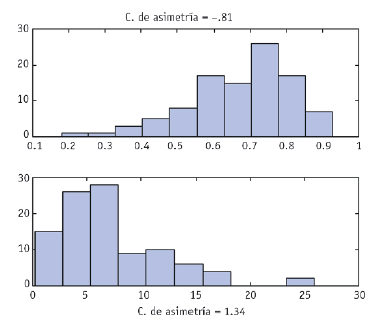



**Kurtosis** es una característica de como la frecuencia relativa se reparte entre el centro y los extremos


$$CA_p=\frac{\sum_{i=1}^n (x_i -\bar{x})^4}{ns^4}$$

Este coeficiente es siempre mayor
o igual que uno. El coeficiente de curtosis es importante porque nos informa respecto a la heterogeneidad de la distribución.

1. Si es muy bajo (menor de 2), indica una distribución mezclada
2. si es muy alto (mayor de 6), indica
la presencia de valores extremos atípicos.


In [ ]:
stats.skew(tips.total_bill) # Calcular el CA

In [ ]:
stats.kurtosis(tips.total_bill) # Calcular el CA_p

In [ ]:
plt.hist(tips.total_bill)

# Datos atipicos

Es muy frecuente que los datos presenten observaciones que contienen
errores de medida o de transcripción o que son heterogéneas con el resto
porque se han obtenido en circunstancias distintas. Llamaremos datos atípicos
a estas observaciones generadas de forma distinta al resto de los datos.


De muchos estudios se ha demostrado que esta proporcion puede variar entre un 1 y un 3% de una muestra. Incluso puede ser >5% si no hay cuidado en la recoleccion

**Como detectarlos?**

1. En estadística, la regla 68-95-99.7, también conocida como regla empírica, es una abreviatura utilizada para recordar el porcentaje de valores que se encuentran dentro de una banda alrededor de la media en una distribución normal con un ancho de dos, cuatro y seis veces la desviación típica, respectivamente. Más exactamente, el 68.27 %, el 95.45 % y el 99.73 % de los valores se encuentran dentro de bandas con semiancho de una, dos y tres veces la desviación típica respecto a la media. Funciona bastante bien, para distribuciones normales o muy cercanas a la normal.
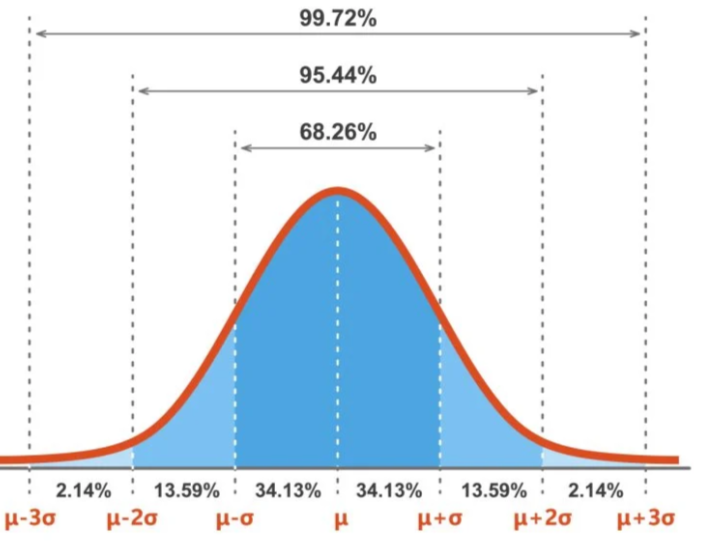

2. Una regla mejor es utilizar valores de centralización y dispersión
que estén poco afectados por valores atípicos, como la mediana y la Meda, pero presenta el inconveniente de no tener en cuenta la asimetría de la distribución

$$x > Med \pm 4.5*MEDA$$

3. Usando el rango intercuartilico

$$x < Q_1 -1.5 IQR$$
$$x > Q_3 +1.5 IQR$$

$\color{red}{\textbf{OJO:}}$ **no siempre se deben eleminar los datos atipicos, a veces estos datos dicen mucho en un analisis descriptivo**

Para detectar atipicos se suele usar el **diagrama de caja o boxplot**

In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")
ax = sns.boxplot(x=tips.total_bill)
plt.title('Boxplot de total facturado')
plt.xlabel('montos de factura')

## Median Absolute Deviation (MAD) para detectar outliers

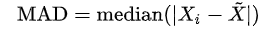

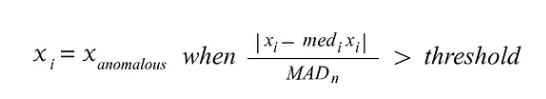

In [ ]:
# ideal para aplicar en  distribuciones asimétricas

# Calcular las desviaciones absolutas medianas
median = np.median(tips.total_bill)
mad = np.median(np.abs(tips.total_bill - median))

# Definir umbral para los outliers por lo general se usa desde 2,5 hasta 3,5
threshold = 3.5

# Detección de outliers
outliers = tips.total_bill[np.abs(tips.total_bill- median) / mad > threshold]

#veamos los resultados finales
print("Outliers detectados por el Método de las Desviaciones Absolutas Medianas (MAD):")
print(outliers)

# https://repository.javeriana.edu.co/bitstream/handle/10554/10347/MorenoCastellanosJuanGabriel2012.pdf

# https://eurekastatistics.com/using-the-median-absolute-deviation-to-find-outliers/

# https://s3.amazonaws.com/media2.fairhealth.org/resource/asset/FH%20Methodology%20-%20Median%20Absolute%20Deviation.pdf

##Cómo tratar los outliers

Una vez que hemos identificado los outliers, es importante tomar decisiones sobre cómo manejarlos. Existen varias opciones disponibles, y la elección entre ellas dependerá del contexto y los objetivos del análisis. Aquí hay algunas estrategias comunes:

Mantener los outliers: En ciertos casos, los outliers pueden ser representativos de un subconjunto particular de los datos y contienen información valiosa. En tales situaciones, podemos optar por mantener los outliers en el conjunto de datos y tenerlos en cuenta en nuestro análisis.

Eliminar los outliers: Si se determina que los outliers son el resultado de errores en la entrada de datos, como errores humanos o de medición, y no podemos corregirlos, una opción es eliminarlos del conjunto de datos. Sin embargo, esta estrategia debe utilizarse con precaución, ya que la eliminación indiscriminada de outliers puede sesgar el análisis y afectar la integridad de los resultados.

Transformación de datos: En lugar de eliminar los outliers, otra estrategia es aplicar transformaciones a los datos para reducir el impacto de los outliers en el análisis. Esto puede incluir la aplicación de logaritmos, escalado o normalización de los datos, lo que puede ayudar a mitigar la influencia de los outliers en ciertos modelos o algoritmos.

Tratamiento especial: En algunos casos, los outliers pueden requerir un tratamiento especial. Esto puede incluir asignarles un valor predeterminado, sustituirlos por valores cercanos o considerarlos como una categoría separada en el análisis.

Es importante tener en cuenta que la elección de la estrategia para tratar los outliers debe basarse en una comprensión profunda del dominio de los datos y el contexto del problema. Además, es recomendable documentar y justificar cualquier decisión tomada con respecto a los outliers, para garantizar la transparencia y replicabilidad del análisis.